# EDA — p18.src_ctacorriente_diario (pseudonimizado)

**Objetivo:** Análisis exploratorio de datos (EDA) inicial sobre el dataset de cuentas corrientes diario pseudonimizado, con el fin de entender el comportamiento de los datos al detalle.

**Archivo:** `p18.src_ctacorriente_diario pseudonimizado.csv`  
**Separador:** `;`  
**Columnas:** `IdCtaCte`, `Saldo`, `FechaIncorporacion`, `FechaCesacion`, `FechaFacturacion`, `Estado`, `ID_AFI`

---
## Índice
1. [Configuración e Importaciones](#1)
2. [Carga de Datos](#2)
3. [Vista General del Dataset](#3)
4. [Análisis de Valores Nulos](#4)
5. [Estadísticas Descriptivas](#5)
6. [Análisis por Columna](#6)
7. [Análisis Temporal](#7)
8. [Cuentas Activas vs Cesadas](#8)
9. [Análisis de Saldo](#9)
10. [Relaciones entre Variables](#10)
11. [Detección de Duplicados y Anomalías](#11)
12. [Conclusiones y Hallazgos Clave](#12)

---
## 1. Configuración e Importaciones <a id='1'></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')

# Estilo global de gráficos
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 2. Carga de Datos <a id='2'></a>

In [3]:
FILE_PATH = 'p18.src_ctacorriente_diario pseudonimizado.csv'

DATE_COLS = ['FechaIncorporacion', 'FechaCesacion', 'FechaFacturacion']

df = pd.read_csv(
    FILE_PATH,
    sep=';',
    parse_dates=DATE_COLS,
    dayfirst=False,
    encoding='utf-8'
)

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head()

Dataset cargado: 324,213 filas x 7 columnas


,IdCtaCte,Saldo,FechaIncorporacion,FechaCesacion,FechaFacturacion,Estado,ID_AFI
0,269861,10150,2025-01-22 20:56:13.140,NaT,2026-01-23,1,AFI_00000362
1,289293,6900,2025-06-26 17:20:02.297,NaT,2026-03-20,1,AFI_00000399
2,118117,11750,2019-04-08 00:00:00.000,2024-06-26 10:38:12.620,2024-05-31,0,AFI_00000347
3,200620,15950,2022-11-20 21:36:51.750,NaT,2026-03-20,1,AFI_00000228
4,258708,2900,2024-10-21 09:09:07.720,2025-04-29 08:22:52.940,2025-03-24,0,AFI_00000237


---
## 3. Vista General del Dataset <a id='3'></a>

In [4]:
print('=== FORMA DEL DATASET ===')
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print()

print('=== TIPOS DE DATOS ===')
print(df.dtypes)
print()

print('=== MEMORIA UTILIZADA ===')
mem = df.memory_usage(deep=True).sum() / 1024**2
print(f'{mem:.2f} MB')

=== FORMA DEL DATASET ===
Filas:    324,213
Columnas: 7

=== TIPOS DE DATOS ===
IdCtaCte                       int64
Saldo                          int64
FechaIncorporacion    datetime64[us]
FechaCesacion         datetime64[us]
FechaFacturacion      datetime64[us]
Estado                         int64
ID_AFI                           str
dtype: object

=== MEMORIA UTILIZADA ===
36.18 MB


In [5]:
print('=== PRIMERAS 10 FILAS ===')
display(df.head(10))

=== PRIMERAS 10 FILAS ===


,IdCtaCte,Saldo,FechaIncorporacion,FechaCesacion,FechaFacturacion,Estado,ID_AFI
0,269861,10150,2025-01-22 20:56:13.140,NaT,2026-01-23,1,AFI_00000362
1,289293,6900,2025-06-26 17:20:02.297,NaT,2026-03-20,1,AFI_00000399
2,118117,11750,2019-04-08 00:00:00.000,2024-06-26 10:38:12.620,2024-05-31,0,AFI_00000347
3,200620,15950,2022-11-20 21:36:51.750,NaT,2026-03-20,1,AFI_00000228
4,258708,2900,2024-10-21 09:09:07.720,2025-04-29 08:22:52.940,2025-03-24,0,AFI_00000237
5,118129,8850,2019-04-08 00:00:00.000,NaT,2026-03-20,1,AFI_00000451
6,229116,10200,2023-12-19 23:04:31.387,2026-02-14 13:41:02.300,2026-01-23,0,AFI_00000144
7,118075,2700,2019-04-08 00:00:00.000,2022-07-20 22:51:46.543,2022-06-16,0,AFI_00000014
8,118111,12000,2019-04-08 00:00:00.000,2025-04-29 08:22:52.940,2025-03-31,0,AFI_00000273
9,289289,6300,2025-06-26 17:20:02.297,NaT,2026-03-20,1,AFI_00000028


In [6]:
print('=== ÚLTIMAS 10 FILAS ===')
display(df.tail(10))

=== ÚLTIMAS 10 FILAS ===


,IdCtaCte,Saldo,FechaIncorporacion,FechaCesacion,FechaFacturacion,Estado,ID_AFI
324203,273750,2000,2025-02-20 00:51:30.113,NaT,2025-12-24,1,AFI_01474954
324204,210531,5500,2023-04-19 12:09:47.673,2024-08-21 21:08:37.640,2024-07-18,0,AFI_01474971
324205,146191,7650,2019-08-21 17:35:48.923,2026-01-23 10:34:46.340,2025-12-24,0,AFI_01475027
324206,117947,11000,2019-04-08 00:00:00.000,NaT,2026-03-31,1,AFI_01475037
324207,273751,10400,2025-02-20 00:51:30.113,NaT,2026-03-20,1,AFI_01475043
324208,117985,34400,2019-04-08 00:00:00.000,NaT,2026-03-31,1,AFI_01475308
324209,273753,11000,2025-02-20 00:51:30.113,NaT,2026-03-20,1,AFI_01475333
324210,117989,12000,2019-04-08 00:00:00.000,2023-07-26 08:32:29.660,2023-06-30,0,AFI_01475348
324211,251302,15850,2024-08-21 21:08:43.387,NaT,2026-03-20,1,AFI_01475753
324212,273755,5000,2025-02-20 00:51:30.113,NaT,2026-03-20,1,AFI_01475768


In [7]:
print('=== MUESTRA ALEATORIA (10 filas) ===')
display(df.sample(10, random_state=42))

=== MUESTRA ALEATORIA (10 filas) ===


,IdCtaCte,Saldo,FechaIncorporacion,FechaCesacion,FechaFacturacion,Estado,ID_AFI
113957,42511,22400,2019-04-08 00:00:00.000,NaT,2026-03-20,1,AFI_01129636
73613,24163,12000,2019-04-08 00:00:00.000,NaT,2026-03-31,1,AFI_01090177
195203,83344,11750,2019-04-08 00:00:00.000,NaT,2026-03-31,1,AFI_01237671
148131,63259,6200,2019-04-08 00:00:00.000,2025-08-25 10:56:48.590,2025-07-25,0,AFI_01176720
178745,77548,31750,2019-04-08 00:00:00.000,2026-01-23 10:34:46.340,2025-12-31,0,AFI_01217037
133861,147233,15200,2019-09-09 14:53:23.347,NaT,2026-03-20,1,AFI_01165233
208080,303113,2000,2025-10-17 20:36:38.820,NaT,2026-03-20,1,AFI_01262835
176842,76922,12050,2019-04-08 00:00:00.000,NaT,2026-03-20,1,AFI_01214918
297495,109238,1000,2019-04-08 00:00:00.000,2019-07-26 10:27:55.843,2019-04-01,0,AFI_01384728
178500,232654,1750,2024-02-28 13:42:02.760,2024-10-21 09:09:03.387,2024-09-23,0,AFI_01215632


---
## 4. Análisis de Valores Nulos <a id='4'></a>

In [8]:
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
nulos['Tipo'] = df.dtypes
nulos = nulos.sort_values('% Nulos', ascending=False)
print('=== RESUMEN DE VALORES NULOS ===')
display(nulos)

=== RESUMEN DE VALORES NULOS ===


,Nulos,% Nulos,Tipo
FechaCesacion,181594,56.01,datetime64[us]
Saldo,0,0.00,int64
IdCtaCte,0,0.00,int64
FechaIncorporacion,0,0.00,datetime64[us]
FechaFacturacion,1,0.00,datetime64[us]
Estado,0,0.00,int64
ID_AFI,0,0.00,str


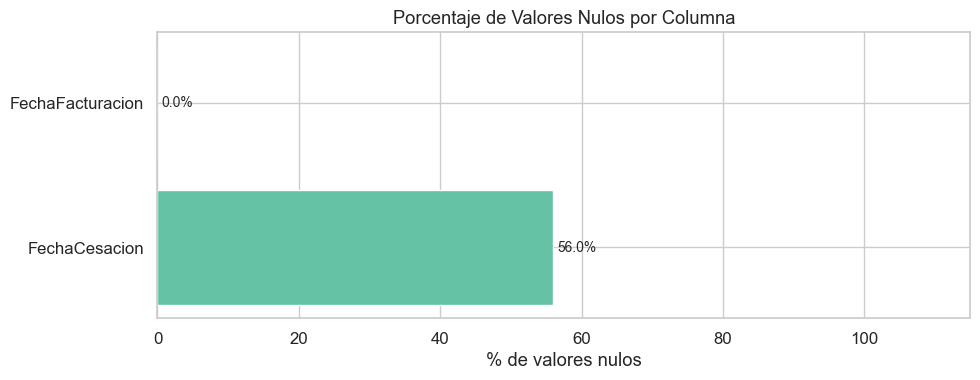

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
cols_con_nulos = nulos[nulos['Nulos'] > 0]

if not cols_con_nulos.empty:
    bars = ax.barh(
        cols_con_nulos.index,
        cols_con_nulos['% Nulos'],
        color=sns.color_palette('Set2', len(cols_con_nulos))
    )
    for bar, val in zip(bars, cols_con_nulos['% Nulos']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)
    ax.set_xlabel('% de valores nulos')
    ax.set_title('Porcentaje de Valores Nulos por Columna')
    ax.set_xlim(0, 115)
else:
    ax.text(0.5, 0.5, 'Sin valores nulos en el dataset', ha='center', va='center',
            fontsize=14, transform=ax.transAxes)
    ax.set_title('Valores Nulos')

plt.tight_layout()
plt.show()

In [10]:
# Patrón de nulidad: ¿los registros con FechaCesacion nula coinciden con Estado=1 (activa)?
print('=== PATRÓN DE NULIDAD: FechaCesacion vs Estado ===')
print(pd.crosstab(
    df['FechaCesacion'].isnull().map({True: 'Sin fecha cesación', False: 'Con fecha cesación'}),
    df['Estado'].map({0: 'Cesada (0)', 1: 'Activa (1)'}),
    margins=True
))

=== PATRÓN DE NULIDAD: FechaCesacion vs Estado ===
Estado              Activa (1)  Cesada (0)     All
FechaCesacion                                     
Con fecha cesación           0      142619  142619
Sin fecha cesación      181594           0  181594
All                     181594      142619  324213


---
## 5. Estadísticas Descriptivas <a id='5'></a>

In [11]:
print('=== ESTADÍSTICAS DESCRIPTIVAS — COLUMNAS NUMÉRICAS ===')
display(df.describe(include=[np.number]).T)

=== ESTADÍSTICAS DESCRIPTIVAS — COLUMNAS NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
IdCtaCte,"324,213.00","162,895.68","93,854.41",2.00,"81,652.00","162,907.00","244,149.00","325,495.00"
Saldo,"324,213.00","9,367.19","7,788.80","-17,100.00","3,200.00","7,800.00","12,000.00","64,000.00"
Estado,"324,213.00",0.56,0.50,0.00,0.00,1.00,1.00,1.00


In [12]:
print('=== ESTADÍSTICAS DESCRIPTIVAS — COLUMNAS FECHA ===')
for col in DATE_COLS:
    print(f'\n--- {col} ---')
    print(f'  Min:    {df[col].min()}')
    print(f'  Max:    {df[col].max()}')
    print(f'  Rango:  {(df[col].max() - df[col].min()).days} días')
    print(f'  Nulos:  {df[col].isnull().sum():,} ({df[col].isnull().mean()*100:.1f}%)')

=== ESTADÍSTICAS DESCRIPTIVAS — COLUMNAS FECHA ===

--- FechaIncorporacion ---
  Min:    2019-04-08 00:00:00
  Max:    2026-03-20 18:40:28.740000
  Rango:  2538 días
  Nulos:  0 (0.0%)

--- FechaCesacion ---
  Min:    2019-05-31 00:00:00
  Max:    2026-03-20 18:40:08.480000
  Rango:  2485 días
  Nulos:  181,594 (56.0%)

--- FechaFacturacion ---
  Min:    2019-04-01 00:00:00
  Max:    2026-04-21 16:08:48.223000
  Rango:  2577 días
  Nulos:  1 (0.0%)


In [13]:
print('=== ESTADÍSTICAS DESCRIPTIVAS — COLUMNAS CATEGÓRICAS/TEXTO ===')
display(df.describe(include=['object', 'category']).T)

=== ESTADÍSTICAS DESCRIPTIVAS — COLUMNAS CATEGÓRICAS/TEXTO ===


,count,unique,top,freq
ID_AFI,324213,304611,AFI_01209842,9


---
## 6. Análisis por Columna <a id='6'></a>

### 6.1 IdCtaCte — Identificador de Cuenta Corriente

In [14]:
print('=== IdCtaCte ===')
print(f'Valores únicos:   {df["IdCtaCte"].nunique():,}')
print(f'Total registros:  {len(df):,}')
print(f'Duplicados:       {len(df) - df["IdCtaCte"].nunique():,}')
print(f'Rango:            [{df["IdCtaCte"].min():,} — {df["IdCtaCte"].max():,}]')
print()

# ¿Hay cuentas con múltiples registros?
dup_cuentas = df['IdCtaCte'].value_counts()
print('Distribución de frecuencia de IdCtaCte:')
print(dup_cuentas.value_counts().head(10).rename_axis('Apariciones').reset_index(name='N° cuentas'))

=== IdCtaCte ===
Valores únicos:   324,213
Total registros:  324,213
Duplicados:       0
Rango:            [2 — 325,495]

Distribución de frecuencia de IdCtaCte:
   Apariciones  N° cuentas
0            1      324213


In [15]:
if df['IdCtaCte'].duplicated().any():
    print('=== TOP 10 CUENTAS CON MÁS REGISTROS ===')
    top_cuentas = df['IdCtaCte'].value_counts().head(10).reset_index()
    top_cuentas.columns = ['IdCtaCte', 'Frecuencia']
    display(top_cuentas)
    
    # Mostrar los registros de la cuenta más repetida
    cuenta_top = df['IdCtaCte'].value_counts().idxmax()
    print(f'\nDetalle de la cuenta más repetida (IdCtaCte={cuenta_top}):')
    display(df[df['IdCtaCte'] == cuenta_top])
else:
    print('IdCtaCte es única por registro (sin duplicados).')

IdCtaCte es única por registro (sin duplicados).


### 6.2 Saldo

In [16]:
print('=== SALDO — Estadísticas ===')
stats_saldo = df['Saldo'].describe(percentiles=[.05, .25, .5, .75, .90, .95, .99])
display(stats_saldo.to_frame().T)
print(f'\nSkewness:  {df["Saldo"].skew():.4f}')
print(f'Kurtosis:  {df["Saldo"].kurtosis():.4f}')
print(f'Negativos: {(df["Saldo"] < 0).sum():,} ({(df["Saldo"] < 0).mean()*100:.2f}%)')
print(f'Ceros:     {(df["Saldo"] == 0).sum():,} ({(df["Saldo"] == 0).mean()*100:.2f}%)')

=== SALDO — Estadísticas ===


,count,mean,std,min,5%,25%,50%,75%,90%,95%,99%,max
Saldo,"324,213.00","9,367.19","7,788.80","-17,100.00","1,000.00","3,200.00","7,800.00","12,000.00","19,750.00","27,400.00","33,600.00","64,000.00"



Skewness:  1.3952
Kurtosis:  1.9741
Negativos: 4 (0.00%)
Ceros:     5,011 (1.55%)


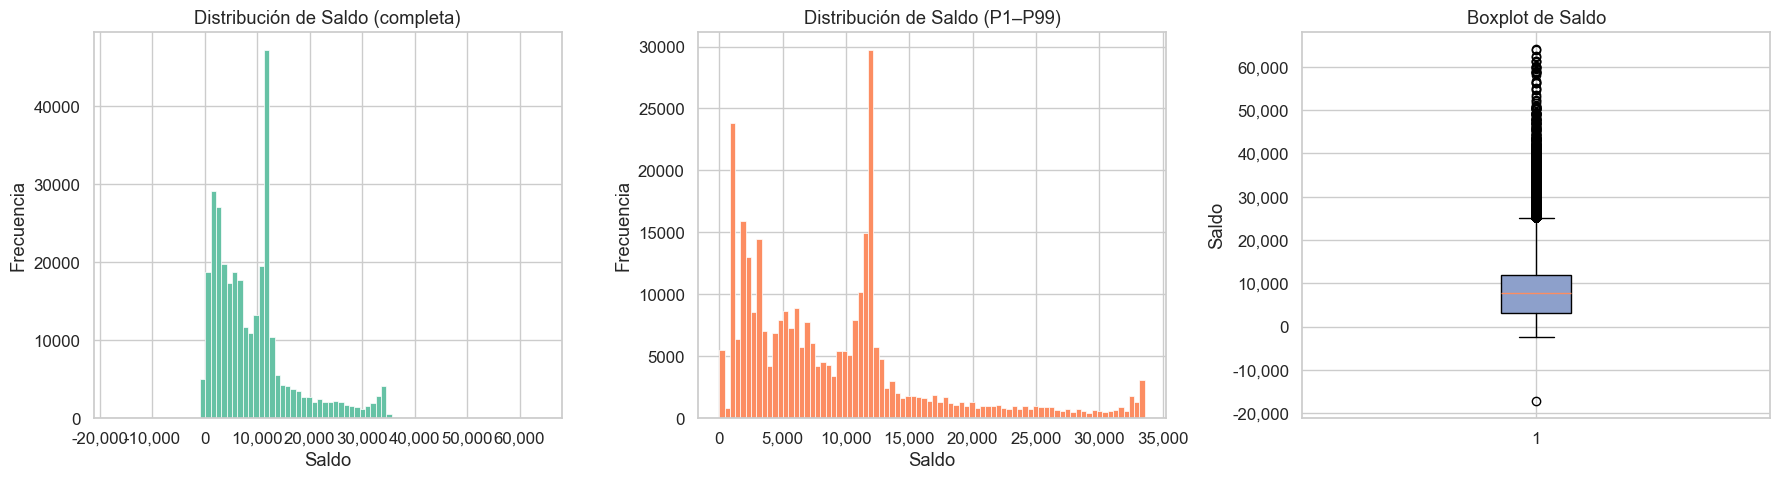

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma completo
axes[0].hist(df['Saldo'], bins=80, color=sns.color_palette('Set2')[0], edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribución de Saldo (completa)')
axes[0].set_xlabel('Saldo')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Histograma sin outliers extremos (percentil 1-99)
p1, p99 = df['Saldo'].quantile(0.01), df['Saldo'].quantile(0.99)
df_sin_outliers = df[(df['Saldo'] >= p1) & (df['Saldo'] <= p99)]
axes[1].hist(df_sin_outliers['Saldo'], bins=80, color=sns.color_palette('Set2')[1], edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribución de Saldo (P1–P99)')
axes[1].set_xlabel('Saldo')
axes[1].set_ylabel('Frecuencia')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Boxplot
axes[2].boxplot(df['Saldo'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette('Set2')[2]))
axes[2].set_title('Boxplot de Saldo')
axes[2].set_ylabel('Saldo')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

In [18]:
# Detección de outliers por IQR
Q1 = df['Saldo'].quantile(0.25)
Q3 = df['Saldo'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Saldo'] < lower) | (df['Saldo'] > upper)]
print(f'=== OUTLIERS EN SALDO (método IQR) ===')
print(f'Límite inferior: {lower:,.2f}')
print(f'Límite superior: {upper:,.2f}')
print(f'Outliers:        {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)')
print()
if not outliers.empty:
    print('Top 10 saldos más altos:')
    display(df.nlargest(10, 'Saldo')[['IdCtaCte', 'Saldo', 'Estado', 'ID_AFI']])
    print('\nTop 10 saldos más bajos:')
    display(df.nsmallest(10, 'Saldo')[['IdCtaCte', 'Saldo', 'Estado', 'ID_AFI']])

=== OUTLIERS EN SALDO (método IQR) ===
Límite inferior: -10,000.00
Límite superior: 25,200.00
Outliers:        20,186 (6.23%)

Top 10 saldos más altos:


,IdCtaCte,Saldo,Estado,ID_AFI
318321,114729,64000,1,AFI_01441427
255563,101636,63950,1,AFI_01326868
42378,146395,62400,1,AFI_00817644
209498,86167,62300,1,AFI_01246623
210767,89343,61450,1,AFI_01259765
39041,134546,61300,1,AFI_00462449
312248,113174,61190,1,AFI_01423826
8758,121365,60250,1,AFI_00041598
40573,137219,60000,1,AFI_00714450
33128,132239,59900,1,AFI_00338129



Top 10 saldos más bajos:


,IdCtaCte,Saldo,Estado,ID_AFI
106832,151753,-17100,0,AFI_01135587
18850,126292,-2300,0,AFI_00129928
285100,106186,-2000,0,AFI_01361012
64099,16878,-950,1,AFI_01067442
55,118115,0,1,AFI_00000334
94,118278,0,1,AFI_00001563
188,165597,0,1,AFI_00000618
189,118281,0,1,AFI_00001572
195,118324,0,1,AFI_00002019
214,139460,0,1,AFI_00002798


### 6.3 Estado

=== ESTADO ===


,Descripción,Cantidad,% del Total
Estado,,,
0,Cesada,142619,43.99
1,Activa,181594,56.01


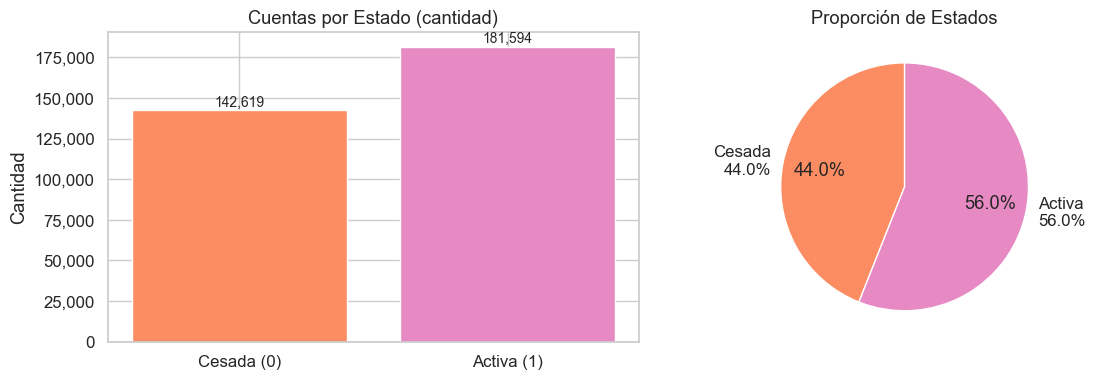

In [19]:
print('=== ESTADO ===')
estado_counts = df['Estado'].value_counts().sort_index()
estado_pct = df['Estado'].value_counts(normalize=True).sort_index() * 100

estado_df = pd.DataFrame({
    'Descripción': estado_counts.index.map({0: 'Cesada', 1: 'Activa'}),
    'Cantidad': estado_counts.values,
    '% del Total': estado_pct.values
}, index=estado_counts.index)
display(estado_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = [sns.color_palette('Set2')[1], sns.color_palette('Set2')[3]]

bars = axes[0].bar(
    ['Cesada (0)', 'Activa (1)'],
    estado_counts.values,
    color=colors,
    edgecolor='white'
)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{bar.get_height():,}', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Cuentas por Estado (cantidad)')
axes[0].set_ylabel('Cantidad')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].pie(
    estado_counts.values,
    labels=[f'Cesada\n{estado_pct.iloc[0]:.1f}%', f'Activa\n{estado_pct.iloc[1]:.1f}%'],
    colors=colors,
    startangle=90,
    autopct='%1.1f%%',
    pctdistance=0.7
)
axes[1].set_title('Proporción de Estados')

plt.tight_layout()
plt.show()

### 6.4 ID_AFI — Identificador de Afiliado (pseudonimizado)

In [20]:
print('=== ID_AFI ===')
print(f'Valores únicos: {df["ID_AFI"].nunique():,}')
print(f'Total registros: {len(df):,}')
print(f'Cuentas por afiliado (promedio): {len(df)/df["ID_AFI"].nunique():.2f}')
print()

ctas_por_afi = df.groupby('ID_AFI')['IdCtaCte'].nunique()
print('Distribución de cuentas por afiliado:')
display(ctas_por_afi.value_counts().head(10).rename_axis('N° cuentas').reset_index(name='N° afiliados'))

print(f'\nAfiliados con 1 cuenta:    {(ctas_por_afi == 1).sum():,} ({(ctas_por_afi == 1).mean()*100:.1f}%)')
print(f'Afiliados con >1 cuenta:   {(ctas_por_afi > 1).sum():,} ({(ctas_por_afi > 1).mean()*100:.1f}%)')

=== ID_AFI ===
Valores únicos: 304,611
Total registros: 324,213
Cuentas por afiliado (promedio): 1.06

Distribución de cuentas por afiliado:


,N° cuentas,N° afiliados
0,1,289184
1,2,12719
2,3,1789
3,4,564
4,5,213
5,6,99
6,7,36
7,8,6
8,9,1



Afiliados con 1 cuenta:    289,184 (94.9%)
Afiliados con >1 cuenta:   15,427 (5.1%)


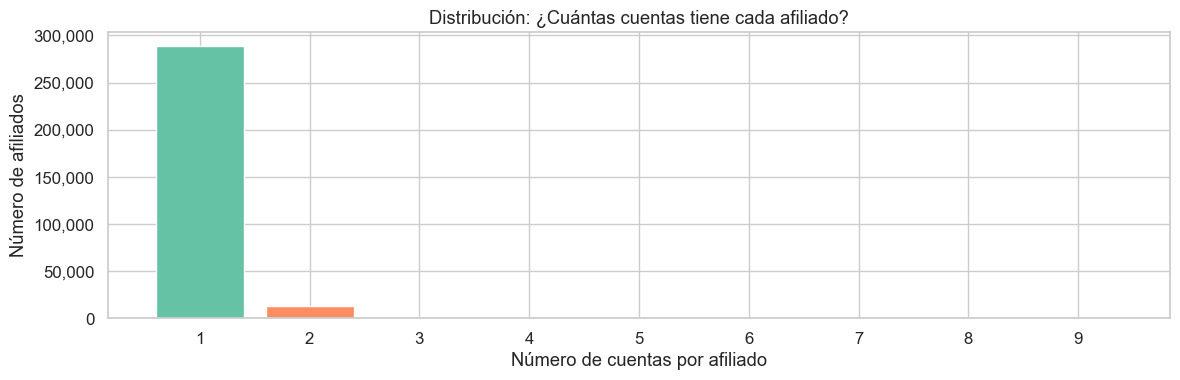

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
ctas_dist = ctas_por_afi.value_counts().sort_index()
top_n = min(15, len(ctas_dist))
ax.bar(
    ctas_dist.index[:top_n].astype(str),
    ctas_dist.values[:top_n],
    color=sns.color_palette('Set2', top_n)
)
ax.set_xlabel('Número de cuentas por afiliado')
ax.set_ylabel('Número de afiliados')
ax.set_title('Distribución: ¿Cuántas cuentas tiene cada afiliado?')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [22]:
print('=== TOP 15 AFILIADOS CON MÁS CUENTAS ===')
top_afiliados = (
    df.groupby('ID_AFI')
    .agg(
        N_Cuentas=('IdCtaCte', 'nunique'),
        Saldo_Total=('Saldo', 'sum'),
        Saldo_Promedio=('Saldo', 'mean'),
        Cuentas_Activas=('Estado', lambda x: (x == 1).sum()),
        Cuentas_Cesadas=('Estado', lambda x: (x == 0).sum())
    )
    .sort_values('N_Cuentas', ascending=False)
    .head(15)
    .reset_index()
)
display(top_afiliados)

=== TOP 15 AFILIADOS CON MÁS CUENTAS ===


,ID_AFI,N_Cuentas,Saldo_Total,Saldo_Promedio,Cuentas_Activas,Cuentas_Cesadas
0,AFI_01209842,9,35700,"3,966.67",1,8
1,AFI_00069156,8,25950,"3,243.75",1,7
2,AFI_00128652,8,22100,"2,762.50",1,7
3,AFI_01280749,8,27150,"3,393.75",1,7
4,AFI_01395546,8,28200,"3,525.00",1,7
5,AFI_00273545,8,26000,"3,250.00",1,7
6,AFI_01356763,8,21450,"2,681.25",1,7
7,AFI_01322560,7,23100,"3,300.00",0,7
8,AFI_00055688,7,20050,"2,864.29",1,6
9,AFI_01150412,7,26050,"3,721.43",1,6


---
## 7. Análisis Temporal <a id='7'></a>

### 7.1 FechaIncorporacion

=== FechaIncorporacion ===
Mínimo: 2019-04-08 00:00:00
Máximo: 2026-03-20 18:40:28.740000
Rango:  2538 días (6.9 años)
Nulos:  0


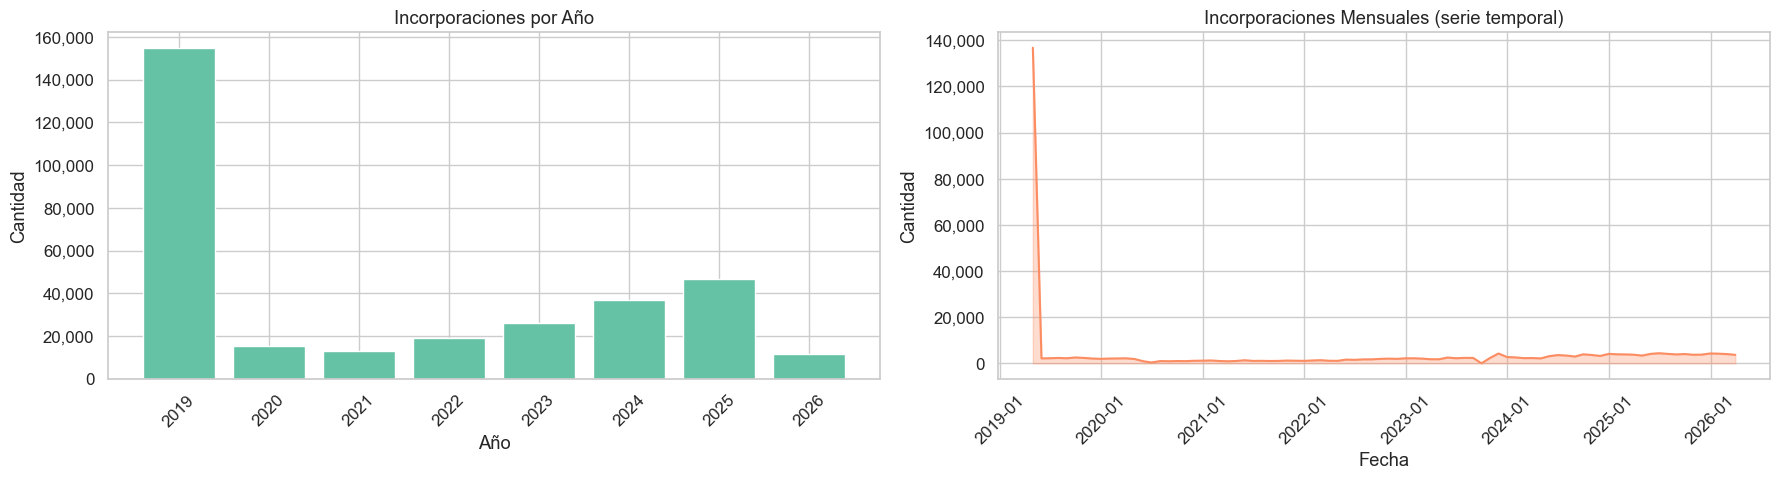

In [23]:
print('=== FechaIncorporacion ===')
fi = df['FechaIncorporacion'].dropna()
print(f'Mínimo: {fi.min()}')
print(f'Máximo: {fi.max()}')
print(f'Rango:  {(fi.max() - fi.min()).days} días ({(fi.max() - fi.min()).days/365.25:.1f} años)')
print(f'Nulos:  {df["FechaIncorporacion"].isnull().sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Por año
por_anio = df['FechaIncorporacion'].dt.year.value_counts().sort_index()
axes[0].bar(por_anio.index.astype(str), por_anio.values, color=sns.color_palette('Set2')[0], edgecolor='white')
axes[0].set_title('Incorporaciones por Año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Por año-mes (serie temporal)
por_mes = df.set_index('FechaIncorporacion').resample('ME').size()
axes[1].plot(por_mes.index, por_mes.values, color=sns.color_palette('Set2')[1], linewidth=1.5)
axes[1].fill_between(por_mes.index, por_mes.values, alpha=0.3, color=sns.color_palette('Set2')[1])
axes[1].set_title('Incorporaciones Mensuales (serie temporal)')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Cantidad')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### 7.2 FechaCesacion

=== FechaCesacion ===
Cuentas con fecha cesación: 142,619 (44.0%)
Mínimo: 2019-05-31 00:00:00
Máximo: 2026-03-20 18:40:08.480000


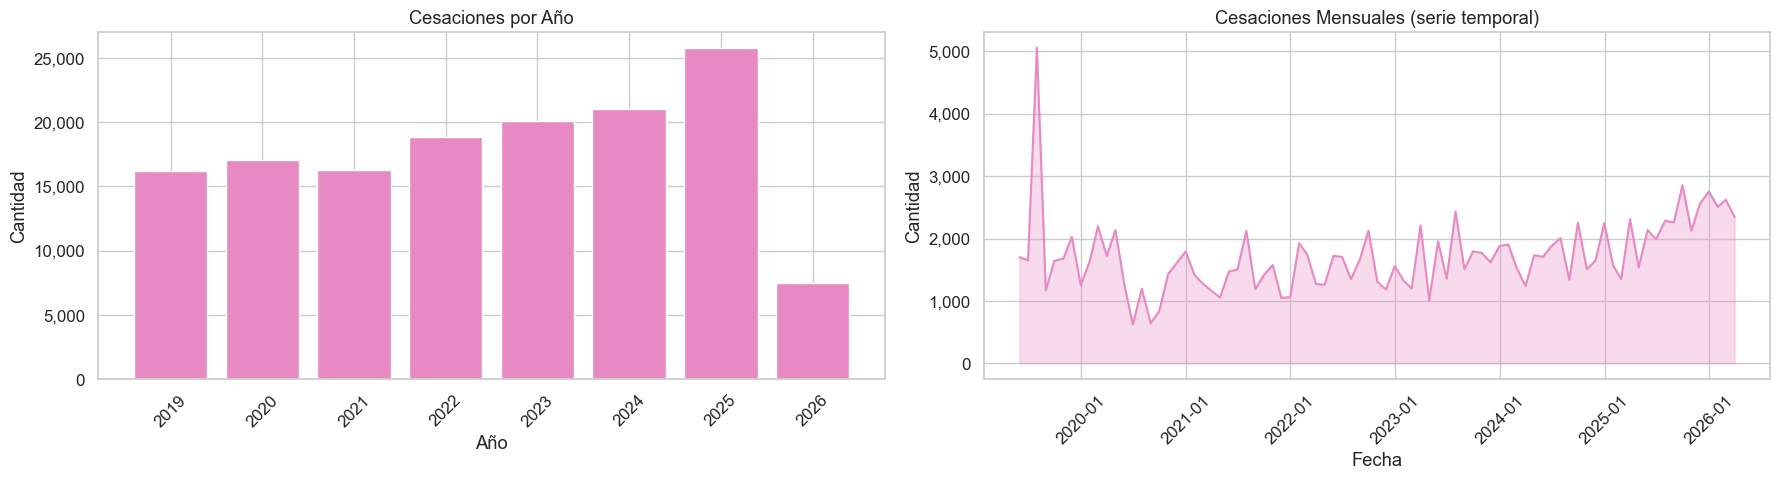

In [24]:
df_cesadas = df[df['FechaCesacion'].notna()].copy()
print(f'=== FechaCesacion ===')
print(f'Cuentas con fecha cesación: {len(df_cesadas):,} ({len(df_cesadas)/len(df)*100:.1f}%)')
print(f'Mínimo: {df_cesadas["FechaCesacion"].min()}')
print(f'Máximo: {df_cesadas["FechaCesacion"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

por_anio_ces = df_cesadas['FechaCesacion'].dt.year.value_counts().sort_index()
axes[0].bar(por_anio_ces.index.astype(str), por_anio_ces.values, color=sns.color_palette('Set2')[3], edgecolor='white')
axes[0].set_title('Cesaciones por Año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

por_mes_ces = df_cesadas.set_index('FechaCesacion').resample('ME').size()
axes[1].plot(por_mes_ces.index, por_mes_ces.values, color=sns.color_palette('Set2')[3], linewidth=1.5)
axes[1].fill_between(por_mes_ces.index, por_mes_ces.values, alpha=0.3, color=sns.color_palette('Set2')[3])
axes[1].set_title('Cesaciones Mensuales (serie temporal)')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Cantidad')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### 7.3 FechaFacturacion

=== FechaFacturacion ===
Registros con fecha facturación: 324,212 (100.0%)
Mínimo: 2019-04-01 00:00:00
Máximo: 2026-04-21 16:08:48.223000


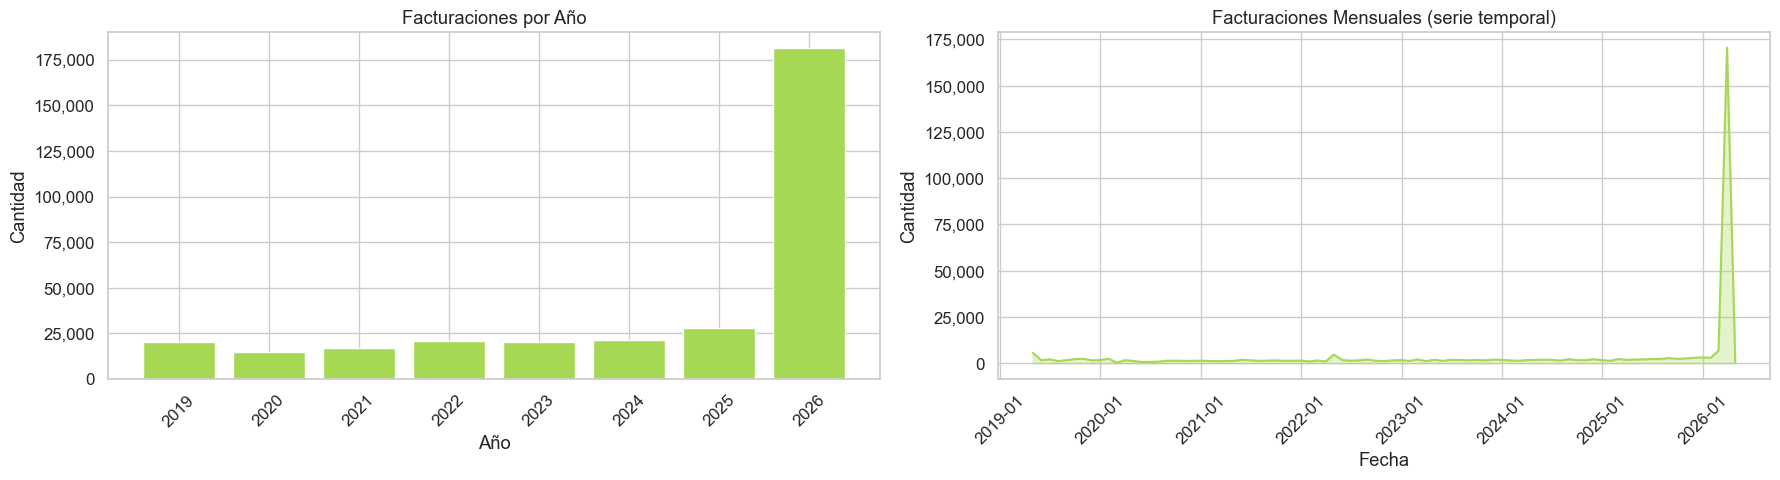

In [25]:
df_fact = df[df['FechaFacturacion'].notna()].copy()
print(f'=== FechaFacturacion ===')
print(f'Registros con fecha facturación: {len(df_fact):,} ({len(df_fact)/len(df)*100:.1f}%)')
print(f'Mínimo: {df_fact["FechaFacturacion"].min()}')
print(f'Máximo: {df_fact["FechaFacturacion"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

por_anio_fact = df_fact['FechaFacturacion'].dt.year.value_counts().sort_index()
axes[0].bar(por_anio_fact.index.astype(str), por_anio_fact.values, color=sns.color_palette('Set2')[4], edgecolor='white')
axes[0].set_title('Facturaciones por Año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

por_mes_fact = df_fact.set_index('FechaFacturacion').resample('ME').size()
axes[1].plot(por_mes_fact.index, por_mes_fact.values, color=sns.color_palette('Set2')[4], linewidth=1.5)
axes[1].fill_between(por_mes_fact.index, por_mes_fact.values, alpha=0.3, color=sns.color_palette('Set2')[4])
axes[1].set_title('Facturaciones Mensuales (serie temporal)')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Cantidad')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### 7.4 Incorporaciones vs Cesaciones (comparativa)

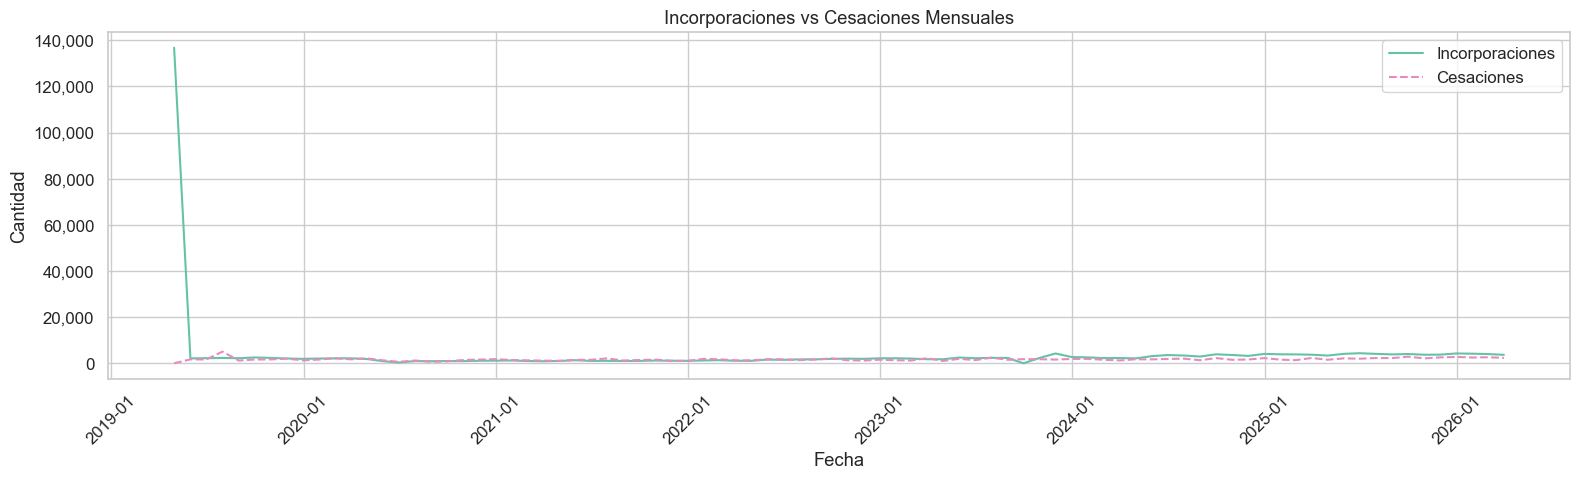

In [26]:
incorp_mensual = df.set_index('FechaIncorporacion').resample('ME').size().rename('Incorporaciones')
cesac_mensual = df_cesadas.set_index('FechaCesacion').resample('ME').size().rename('Cesaciones')

temporal_df = pd.concat([incorp_mensual, cesac_mensual], axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(temporal_df.index, temporal_df['Incorporaciones'], label='Incorporaciones', color=sns.color_palette('Set2')[0], linewidth=1.5)
ax.plot(temporal_df.index, temporal_df['Cesaciones'], label='Cesaciones', color=sns.color_palette('Set2')[3], linewidth=1.5, linestyle='--')
ax.set_title('Incorporaciones vs Cesaciones Mensuales')
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

---
## 8. Cuentas Activas vs Cesadas <a id='8'></a>

In [27]:
print('=== SALDO SEGÚN ESTADO ===')
saldo_por_estado = df.groupby('Estado')['Saldo'].describe(percentiles=[.25, .5, .75, .95]).round(2)
saldo_por_estado.index = saldo_por_estado.index.map({0: 'Cesada (0)', 1: 'Activa (1)'})
display(saldo_por_estado)

=== SALDO SEGÚN ESTADO ===


,count,mean,std,min,25%,50%,75%,95%,max
Estado,,,,,,,,,
Cesada (0),"142,619.00","8,448.37","7,341.50","-17,100.00","2,750.00","6,500.00","11,750.00","25,350.00","49,000.00"
Activa (1),"181,594.00","10,088.80","8,049.68",-950.00,"3,650.00","9,550.00","12,000.00","28,800.00","64,000.00"


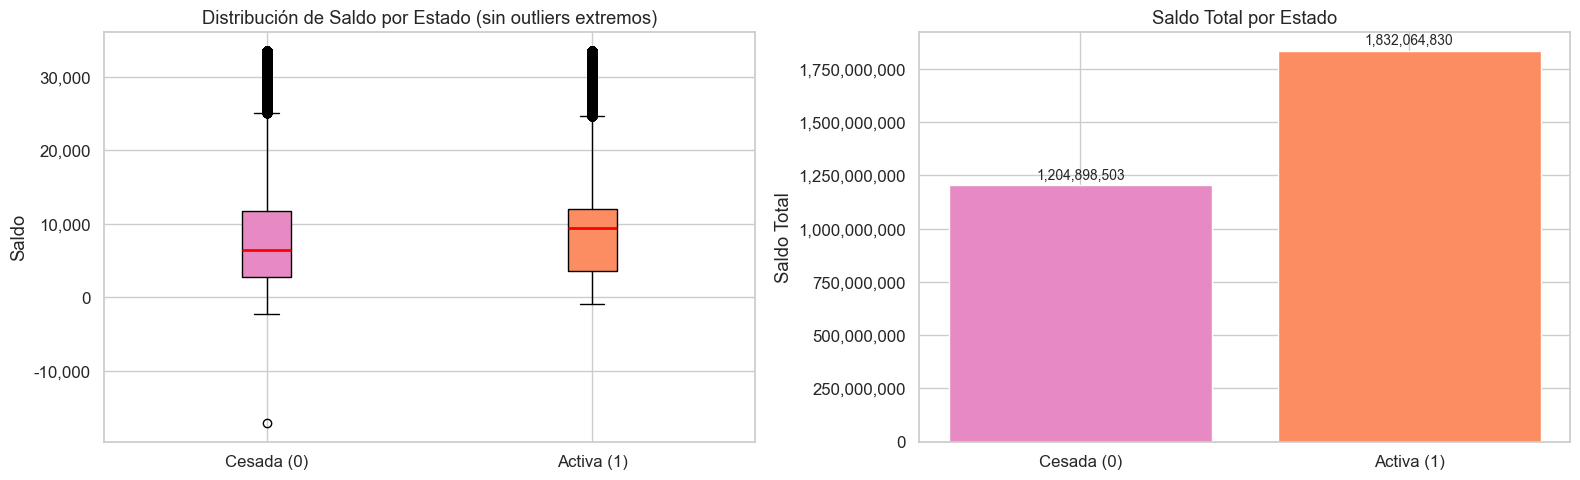

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot saldo por estado
df_plot = df.copy()
df_plot['Estado_label'] = df_plot['Estado'].map({0: 'Cesada', 1: 'Activa'})

# Usar percentil 99 para evitar distorsión por outliers
p99 = df['Saldo'].quantile(0.99)
df_plot_trimmed = df_plot[df_plot['Saldo'] <= p99]

groups = [df_plot_trimmed[df_plot_trimmed['Estado'] == v]['Saldo'].values for v in [0, 1]]
bp = axes[0].boxplot(groups, labels=['Cesada (0)', 'Activa (1)'], patch_artist=True,
                     boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], [sns.color_palette('Set2')[3], sns.color_palette('Set2')[1]]):
    patch.set_facecolor(color)
axes[0].set_title('Distribución de Saldo por Estado (sin outliers extremos)')
axes[0].set_ylabel('Saldo')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Saldo total por estado
saldo_total = df.groupby('Estado')['Saldo'].sum()
saldo_total.index = ['Cesada (0)', 'Activa (1)']
bars = axes[1].bar(saldo_total.index, saldo_total.values,
                   color=[sns.color_palette('Set2')[3], sns.color_palette('Set2')[1]])
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Saldo Total por Estado')
axes[1].set_ylabel('Saldo Total')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

=== DURACIÓN DE VIDA DE CUENTAS CESADAS (días) ===


,count,mean,std,min,25%,50%,75%,90%,95%,max
dias_vida,"142,619.00",816.66,673.73,2.00,252.00,583.00,"1,268.00","1,914.00","2,222.00","2,538.00"


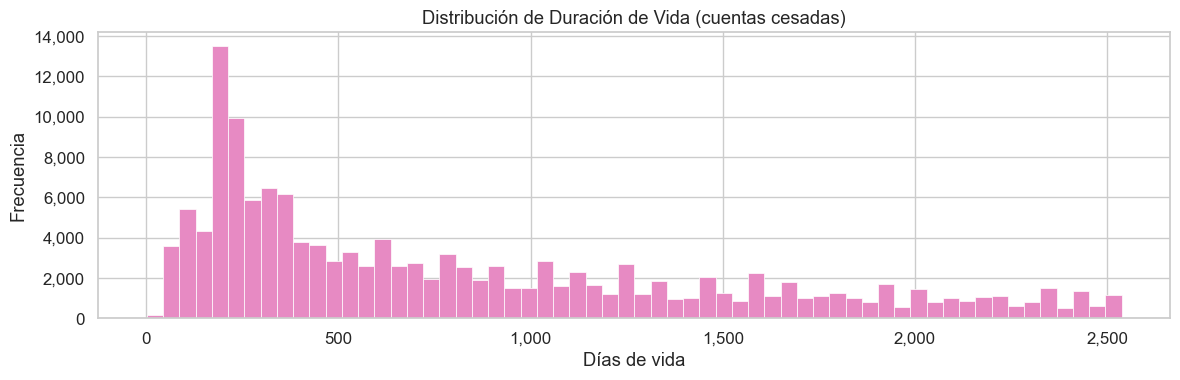

In [29]:
# Duración de vida de las cuentas cesadas
df_cesadas2 = df[df['FechaCesacion'].notna() & df['FechaIncorporacion'].notna()].copy()
df_cesadas2['dias_vida'] = (df_cesadas2['FechaCesacion'] - df_cesadas2['FechaIncorporacion']).dt.days

print('=== DURACIÓN DE VIDA DE CUENTAS CESADAS (días) ===')
display(df_cesadas2['dias_vida'].describe(percentiles=[.25, .5, .75, .90, .95]).to_frame().T)

fig, ax = plt.subplots(figsize=(12, 4))
df_cesadas2['dias_vida'].clip(lower=0).hist(bins=60, ax=ax,
    color=sns.color_palette('Set2')[3], edgecolor='white', linewidth=0.5)
ax.set_title('Distribución de Duración de Vida (cuentas cesadas)')
ax.set_xlabel('Días de vida')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

---
## 9. Análisis de Saldo <a id='9'></a>

=== SEGMENTACIÓN DE SALDO ===


,Cantidad,% del Total
Segmento_Saldo,,
Negativo,5015,1.55
$0–$1k,18606,5.74
$1k–$5k,90988,28.06
$5k–$10k,71320,22.00
$10k–$25k,117663,36.29
$25k–$50k,20577,6.35
$50k–$100k,44,0.01
>$100k,0,0.00


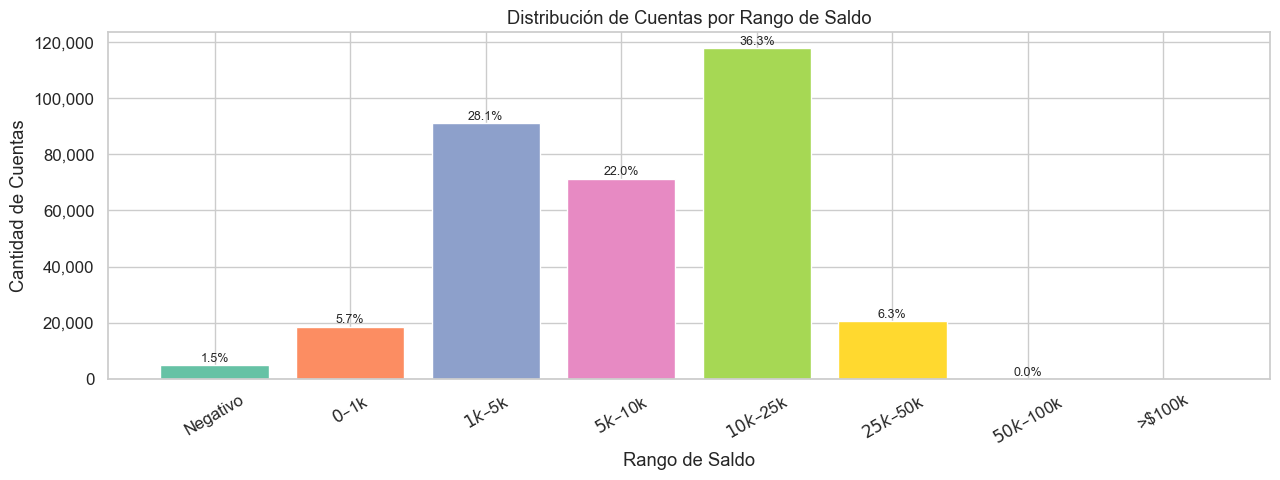

In [30]:
# Segmentación de saldo en rangos
bins_saldo = [-np.inf, 0, 1000, 5000, 10000, 25000, 50000, 100000, np.inf]
labels_saldo = ['Negativo', '$0–$1k', '$1k–$5k', '$5k–$10k', '$10k–$25k', '$25k–$50k', '$50k–$100k', '>$100k']

df['Segmento_Saldo'] = pd.cut(df['Saldo'], bins=bins_saldo, labels=labels_saldo)

seg_counts = df['Segmento_Saldo'].value_counts().reindex(labels_saldo)
seg_pct = seg_counts / len(df) * 100

seg_df = pd.DataFrame({'Cantidad': seg_counts, '% del Total': seg_pct.round(2)})
print('=== SEGMENTACIÓN DE SALDO ===')
display(seg_df)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(labels_saldo, seg_counts.values, color=sns.color_palette('Set2', len(labels_saldo)), edgecolor='white')
for bar, pct in zip(bars, seg_pct.values):
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_title('Distribución de Cuentas por Rango de Saldo')
ax.set_xlabel('Rango de Saldo')
ax.set_ylabel('Cantidad de Cuentas')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [31]:
# Segmentación cruzada: saldo por estado
seg_estado = pd.crosstab(
    df['Segmento_Saldo'],
    df['Estado'].map({0: 'Cesada', 1: 'Activa'}),
    margins=True
)
print('=== SEGMENTO DE SALDO × ESTADO ===')
display(seg_estado)

=== SEGMENTO DE SALDO × ESTADO ===


Estado,Activa,Cesada,All
Segmento_Saldo,,,
Negativo,4346,669,5015
$0–$1k,10101,8505,18606
$1k–$5k,41454,49534,90988
$5k–$10k,37891,33429,71320
$10k–$25k,74570,43093,117663
$25k–$50k,13188,7389,20577
$50k–$100k,44,0,44
All,181594,142619,324213


---
## 10. Relaciones entre Variables <a id='10'></a>

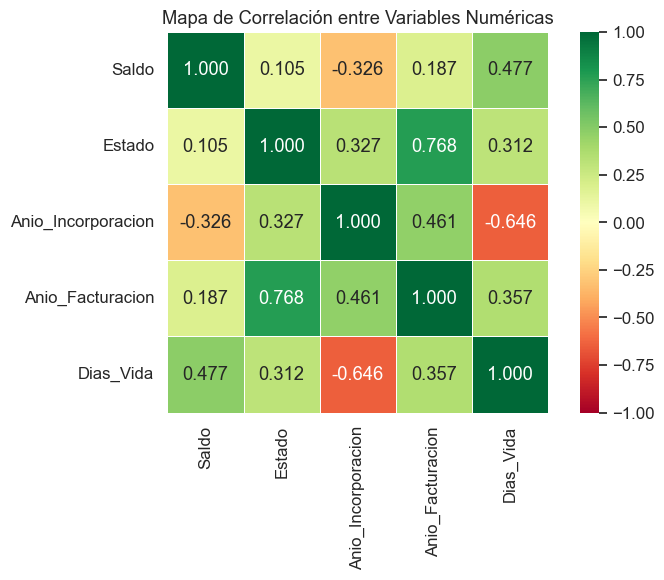

In [32]:
# Correlación entre variables numéricas
df_num = df[['Saldo', 'Estado']].copy()
df_num['Anio_Incorporacion'] = df['FechaIncorporacion'].dt.year
df_num['Anio_Facturacion'] = df['FechaFacturacion'].dt.year
df_num['Dias_Vida'] = (
    df['FechaCesacion'].fillna(pd.Timestamp.now()) - df['FechaIncorporacion']
).dt.days

corr = df_num.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    square=True
)
ax.set_title('Mapa de Correlación entre Variables Numéricas')
plt.tight_layout()
plt.show()

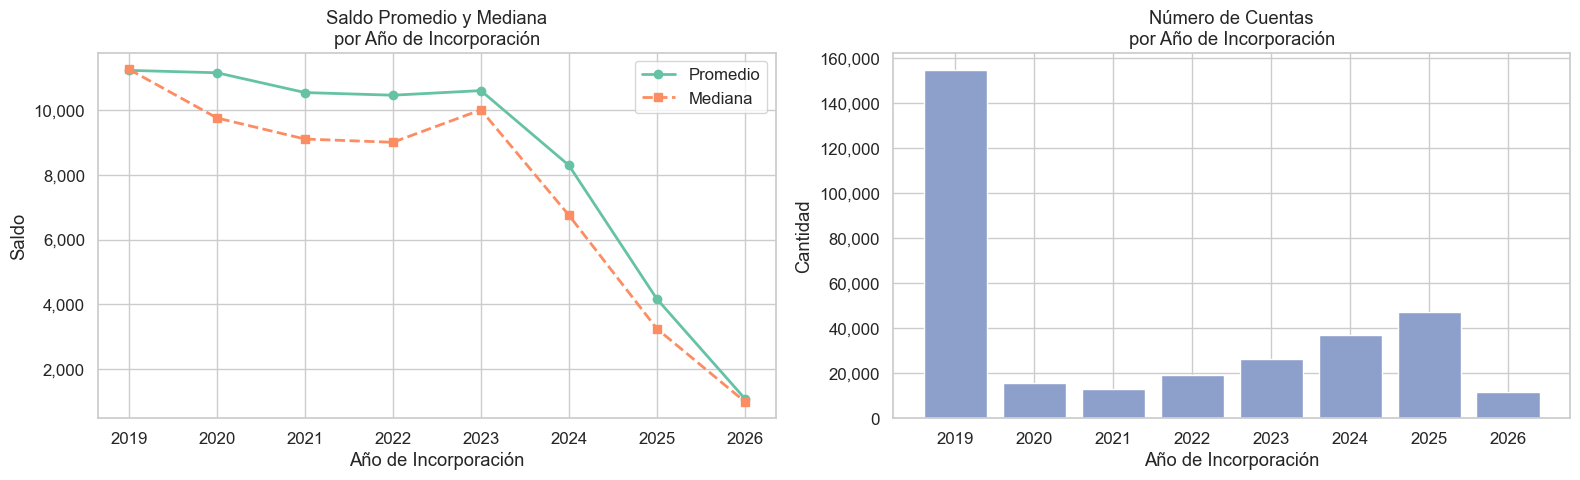

In [33]:
# Saldo promedio por año de incorporación
saldo_por_anio = (
    df.groupby(df['FechaIncorporacion'].dt.year)['Saldo']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'Promedio', 'median': 'Mediana', 'count': 'N'})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(saldo_por_anio.index, saldo_por_anio['Promedio'], marker='o',
             color=sns.color_palette('Set2')[0], label='Promedio', linewidth=2)
axes[0].plot(saldo_por_anio.index, saldo_por_anio['Mediana'], marker='s',
             color=sns.color_palette('Set2')[1], label='Mediana', linewidth=2, linestyle='--')
axes[0].set_title('Saldo Promedio y Mediana\npor Año de Incorporación')
axes[0].set_xlabel('Año de Incorporación')
axes[0].set_ylabel('Saldo')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Cantidad de cuentas por año de incorporación
axes[1].bar(saldo_por_anio.index, saldo_por_anio['N'],
            color=sns.color_palette('Set2')[2], edgecolor='white')
axes[1].set_title('Número de Cuentas\npor Año de Incorporación')
axes[1].set_xlabel('Año de Incorporación')
axes[1].set_ylabel('Cantidad')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

---
## 11. Detección de Duplicados y Anomalías <a id='11'></a>

In [34]:
print('=== DUPLICADOS EN EL DATASET ===')
n_dup_filas = df.duplicated().sum()
print(f'Filas completamente duplicadas: {n_dup_filas:,}')

n_dup_id = df.duplicated(subset=['IdCtaCte']).sum()
print(f'IdCtaCte duplicados:            {n_dup_id:,}')

if n_dup_filas > 0:
    print('\nEjemplos de filas duplicadas:')
    display(df[df.duplicated(keep=False)].head(10))

=== DUPLICADOS EN EL DATASET ===
Filas completamente duplicadas: 0
IdCtaCte duplicados:            0


In [35]:
print('=== ANOMALÍAS TEMPORALES ===')

# Cuentas donde FechaCesacion < FechaIncorporacion
anom1 = df[df['FechaCesacion'].notna() & (df['FechaCesacion'] < df['FechaIncorporacion'])]
print(f'FechaCesacion < FechaIncorporacion: {len(anom1):,} registros')
if not anom1.empty:
    display(anom1.head(5))

# Cuentas Estado=0 sin FechaCesacion
anom2 = df[(df['Estado'] == 0) & df['FechaCesacion'].isnull()]
print(f'\nEstado=0 (Cesada) sin FechaCesacion: {len(anom2):,} registros')
if not anom2.empty:
    display(anom2.head(5))

# Cuentas Estado=1 con FechaCesacion
anom3 = df[(df['Estado'] == 1) & df['FechaCesacion'].notna()]
print(f'\nEstado=1 (Activa) con FechaCesacion: {len(anom3):,} registros')
if not anom3.empty:
    display(anom3.head(5))

=== ANOMALÍAS TEMPORALES ===
FechaCesacion < FechaIncorporacion: 0 registros

Estado=0 (Cesada) sin FechaCesacion: 0 registros

Estado=1 (Activa) con FechaCesacion: 0 registros


In [36]:
print('=== SALDOS ANÓMALOS ===')
# Saldos negativos
saldo_neg = df[df['Saldo'] < 0]
print(f'Saldos negativos: {len(saldo_neg):,} ({len(saldo_neg)/len(df)*100:.2f}%)')
if not saldo_neg.empty:
    print('Distribución de saldos negativos:')
    display(saldo_neg['Saldo'].describe().to_frame().T)

# Saldos extremos (> 3 desvíos estándar)
mean_s = df['Saldo'].mean()
std_s = df['Saldo'].std()
saldo_ext = df[np.abs(df['Saldo'] - mean_s) > 3 * std_s]
print(f'\nSaldos > 3σ de la media: {len(saldo_ext):,} ({len(saldo_ext)/len(df)*100:.2f}%)')

=== SALDOS ANÓMALOS ===
Saldos negativos: 4 (0.00%)
Distribución de saldos negativos:


,count,mean,std,min,25%,50%,75%,max
Saldo,4.00,"-5,587.50","7,696.79","-17,100.00","-6,000.00","-2,150.00","-1,737.50",-950.00



Saldos > 3σ de la media: 7,549 (2.33%)


---
## 12. Conclusiones y Hallazgos Clave <a id='12'></a>

In [37]:
# Resumen ejecutivo automático
n_total = len(df)
n_activas = (df['Estado'] == 1).sum()
n_cesadas = (df['Estado'] == 0).sum()
n_afiliados = df['ID_AFI'].nunique()
saldo_total = df['Saldo'].sum()
saldo_mediana = df['Saldo'].median()
nulos_cesacion = df['FechaCesacion'].isnull().sum()
fecha_min_incorp = df['FechaIncorporacion'].min()
fecha_max_incorp = df['FechaIncorporacion'].max()

print('=' * 65)
print('          RESUMEN EJECUTIVO — EDA CUENTAS CORRIENTES')
print('=' * 65)
print(f'  Total de registros:          {n_total:>12,}')
print(f'  Cuentas activas (Estado=1):  {n_activas:>12,}  ({n_activas/n_total*100:.1f}%)')
print(f'  Cuentas cesadas (Estado=0):  {n_cesadas:>12,}  ({n_cesadas/n_total*100:.1f}%)')
print(f'  Afiliados únicos (ID_AFI):   {n_afiliados:>12,}')
print(f'  Saldo total:                 {saldo_total:>12,.0f}')
print(f'  Saldo mediano:               {saldo_mediana:>12,.0f}')
print(f'  Saldo promedio:              {df["Saldo"].mean():>12,.0f}')
print(f'  Incorporaciones desde:       {str(fecha_min_incorp)[:10]:>12}')
print(f'  Incorporaciones hasta:       {str(fecha_max_incorp)[:10]:>12}')
print(f'  Sin FechaCesacion (nulos):   {nulos_cesacion:>12,}  ({nulos_cesacion/n_total*100:.1f}%)')
print('=' * 65)
print()
print('HALLAZGOS PRINCIPALES:')
print(f'  1. El dataset contiene {n_total:,} registros de cuentas corrientes.')
print(f'  2. La mayoría ({n_activas/n_total*100:.1f}%) son cuentas activas.')
print(f'  3. El saldo mediano es {saldo_mediana:,.0f}, indicando asimetría en la distribución.')
print(f'  4. {nulos_cesacion/n_total*100:.1f}% de los registros no tienen FechaCesacion (cuentas activas).')
print(f'  5. Hay {n_afiliados:,} afiliados únicos, con un promedio de {n_total/n_afiliados:.2f} cuentas por afiliado.')
print(f'  6. Los saldos negativos representan un {(df["Saldo"]<0).mean()*100:.2f}% del total.')

          RESUMEN EJECUTIVO — EDA CUENTAS CORRIENTES
  Total de registros:               324,213
  Cuentas activas (Estado=1):       181,594  (56.0%)
  Cuentas cesadas (Estado=0):       142,619  (44.0%)
  Afiliados únicos (ID_AFI):        304,611
  Saldo total:                 3,036,963,333
  Saldo mediano:                      7,800
  Saldo promedio:                     9,367
  Incorporaciones desde:         2019-04-08
  Incorporaciones hasta:         2026-03-20
  Sin FechaCesacion (nulos):        181,594  (56.0%)

HALLAZGOS PRINCIPALES:
  1. El dataset contiene 324,213 registros de cuentas corrientes.
  2. La mayoría (56.0%) son cuentas activas.
  3. El saldo mediano es 7,800, indicando asimetría en la distribución.
  4. 56.0% de los registros no tienen FechaCesacion (cuentas activas).
  5. Hay 304,611 afiliados únicos, con un promedio de 1.06 cuentas por afiliado.
  6. Los saldos negativos representan un 0.00% del total.


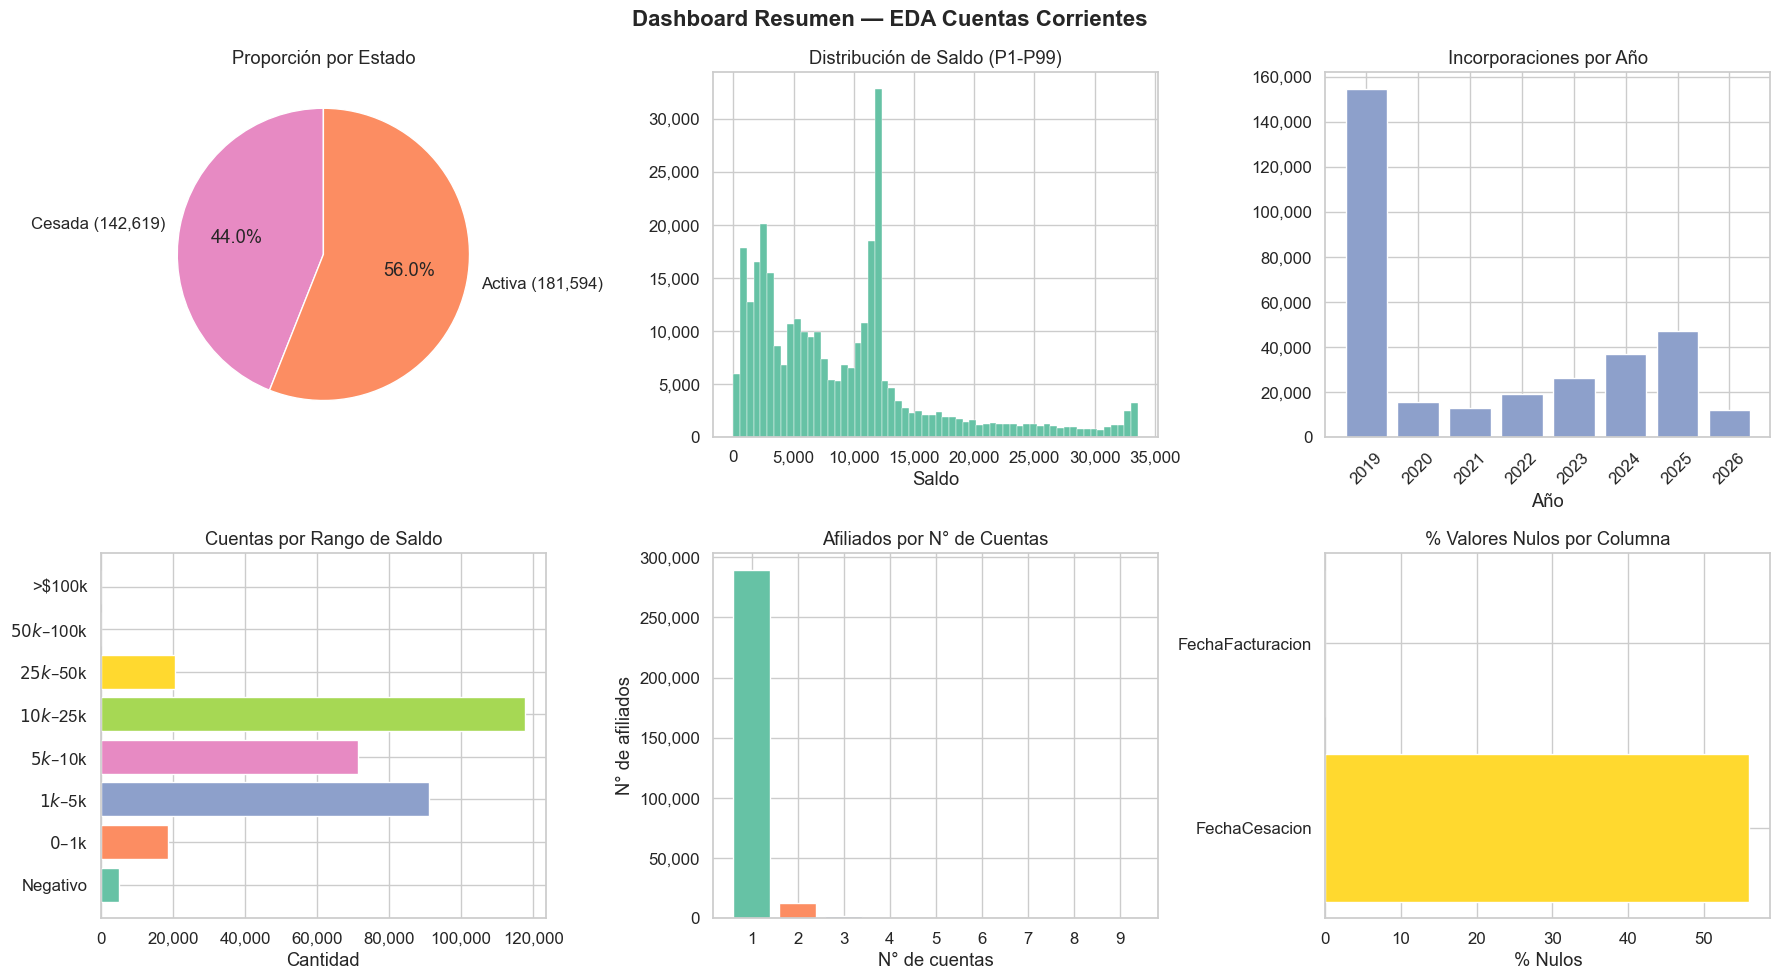

In [38]:
# Dashboard final de resumen
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Dashboard Resumen — EDA Cuentas Corrientes', fontsize=16, fontweight='bold', y=0.98)

# 1. Estado (pie)
ax1 = fig.add_subplot(2, 3, 1)
estado_counts = df['Estado'].value_counts().sort_index()
ax1.pie(
    estado_counts.values,
    labels=[f'Cesada ({estado_counts.values[0]:,})', f'Activa ({estado_counts.values[1]:,})'],
    colors=[sns.color_palette('Set2')[3], sns.color_palette('Set2')[1]],
    autopct='%1.1f%%', startangle=90
)
ax1.set_title('Proporción por Estado')

# 2. Histograma Saldo (sin outliers)
ax2 = fig.add_subplot(2, 3, 2)
p1, p99 = df['Saldo'].quantile(0.01), df['Saldo'].quantile(0.99)
saldo_trim = df.loc[(df['Saldo'] >= p1) & (df['Saldo'] <= p99), 'Saldo']
ax2.hist(saldo_trim, bins=60, color=sns.color_palette('Set2')[0], edgecolor='white', linewidth=0.3)
ax2.set_title('Distribución de Saldo (P1-P99)')
ax2.set_xlabel('Saldo')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 3. Incorporaciones por año
ax3 = fig.add_subplot(2, 3, 3)
por_anio_incorp = df['FechaIncorporacion'].dt.year.value_counts().sort_index()
ax3.bar(por_anio_incorp.index.astype(str), por_anio_incorp.values,
        color=sns.color_palette('Set2')[2], edgecolor='white')
ax3.set_title('Incorporaciones por Año')
ax3.set_xlabel('Año')
ax3.tick_params(axis='x', rotation=45)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 4. Saldo por segmento
ax4 = fig.add_subplot(2, 3, 4)
seg_c = df['Segmento_Saldo'].value_counts().reindex(labels_saldo)
ax4.barh(labels_saldo, seg_c.values, color=sns.color_palette('Set2', len(labels_saldo)))
ax4.set_title('Cuentas por Rango de Saldo')
ax4.set_xlabel('Cantidad')
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 5. Cuentas por afiliado
ax5 = fig.add_subplot(2, 3, 5)
ctas_afi_dist = df.groupby('ID_AFI')['IdCtaCte'].nunique().value_counts().sort_index()
top = min(10, len(ctas_afi_dist))
ax5.bar(ctas_afi_dist.index[:top].astype(str), ctas_afi_dist.values[:top],
        color=sns.color_palette('Set2', top))
ax5.set_title('Afiliados por N° de Cuentas')
ax5.set_xlabel('N° de cuentas')
ax5.set_ylabel('N° de afiliados')
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 6. Valores nulos
ax6 = fig.add_subplot(2, 3, 6)
nulos_col = df.isnull().sum()
nulos_col = nulos_col[nulos_col > 0]
if not nulos_col.empty:
    ax6.barh(nulos_col.index, (nulos_col / len(df) * 100).values,
             color=sns.color_palette('Set2')[5])
    ax6.set_xlabel('% Nulos')
    ax6.set_title('% Valores Nulos por Columna')
else:
    ax6.text(0.5, 0.5, 'Sin valores nulos', ha='center', va='center',
             fontsize=14, transform=ax6.transAxes)
    ax6.set_title('Valores Nulos')

plt.tight_layout()
plt.show()